In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [2]:
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'

In [3]:
df = pd.read_csv(url)
df.sample(5)
df.shape

(891, 12)

In [4]:
df.isna().sum()
df = df.dropna()
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S


In [5]:
x = df[['Pclass',
'Sex',
'Age',
'Fare',
'Embarked']]
y = df['Survived']

In [6]:
x.head()

,Pclass,Sex,Age,Fare,Embarked
1,1,female,38.0,71.2833,C
3,1,female,35.0,53.1000,S
6,1,male,54.0,51.8625,S
10,3,female,4.0,16.7000,S
11,1,female,58.0,26.5500,S


In [7]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()
x[['Sex', 'Embarked']] = encoder.fit_transform(x[['Sex', 'Embarked']])

/tmp/ipykernel_457/1092669459.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[['Sex', 'Embarked']] = encoder.fit_transform(x[['Sex', 'Embarked']])


In [8]:
y.head()

,Survived
1,1
3,1
6,0
10,1
11,1


In [9]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV

In [11]:
decision_tree = DecisionTreeClassifier()

decision_tree.fit(x_train, y_train)

DecisionTreeClassifier()

In [12]:
y_pred = decision_tree.predict(x_test)

In [13]:
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.7567567567567568
[[ 7  7]
 [ 2 21]]
              precision    recall  f1-score   support

           0       0.78      0.50      0.61        14
           1       0.75      0.91      0.82        23

    accuracy                           0.76        37
   macro avg       0.76      0.71      0.72        37
weighted avg       0.76      0.76      0.74        37



In [14]:
grid = {
    'criterion':['gini', 'entropy'],
    'max_depth': [3,4,5,6,7,8,9,10, None]
}

In [15]:
grid_cv = GridSearchCV(
    estimator = decision_tree,
    param_grid = grid,
    cv = 10
)
grid_cv.fit(x_train, y_train)

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 4, 5, 6, 7, 8, 9, 10, None]})

In [16]:
y_pred = grid_cv.predict(x_test)
print(accuracy_score(y_test, y_pred))


0.6756756756756757


In [17]:
y_pred1 = grid_cv.predict(x_train)
print(accuracy_score(y_train, y_pred1))

1.0


In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.60      0.43      0.50        14
           1       0.70      0.83      0.76        23

    accuracy                           0.68        37
   macro avg       0.65      0.63      0.63        37
weighted avg       0.66      0.68      0.66        37



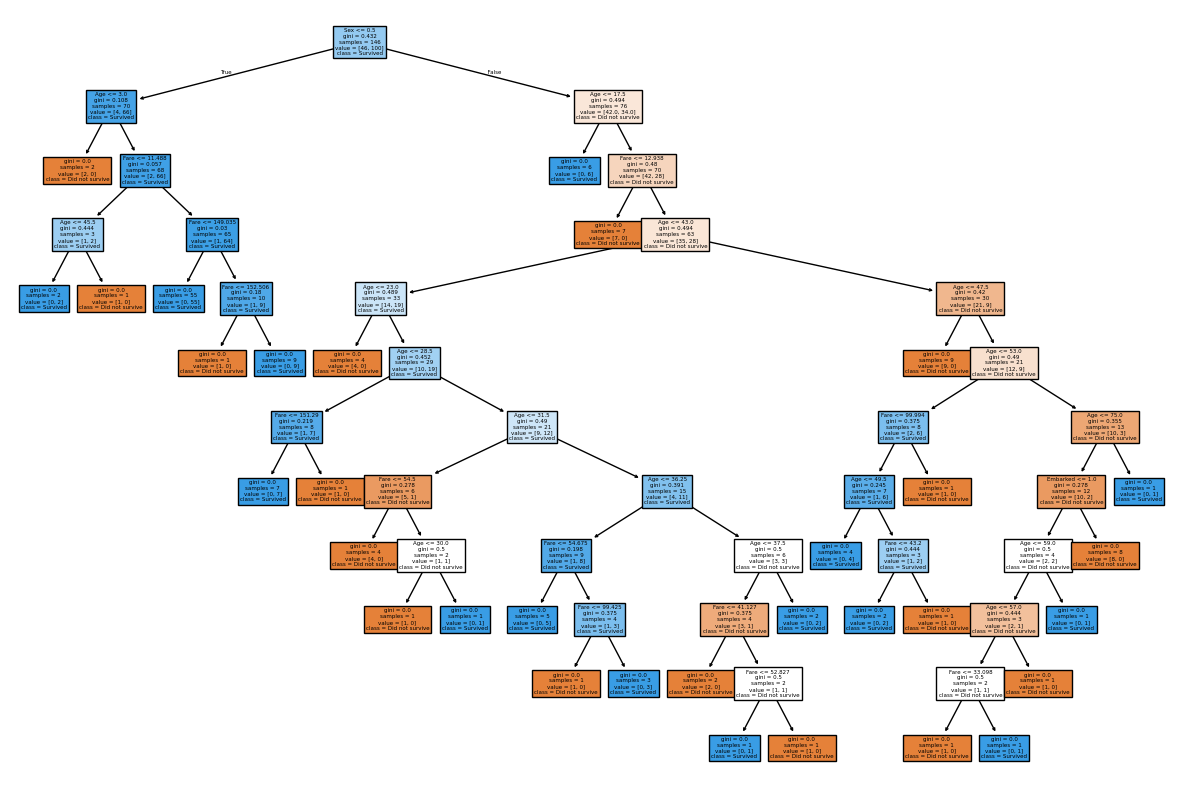

In [19]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

plot_tree(
    decision_tree,
    feature_names=['Pclass',
'Sex',
'Age',
'Fare',
'Embarked'],
    class_names=['Did not survive', 'Survived'],
    filled=True
)

plt.show()

In [20]:
decision_tree = DecisionTreeClassifier(max_depth= 5)

decision_tree.fit(x_train, y_train)

y_pred1 = decision_tree.predict(x_train)
print(accuracy_score(y_train, y_pred1))
y_pred2 = decision_tree.predict(x_test)
print(accuracy_score(y_test, y_pred2))


0.8698630136986302
0.7567567567567568
